# 01 — EDA: Klasifikasi Multikelas Volatilitas USD/IDR

Notebook menganalisis data JISDOR dan berita CNBC untuk target **low, medium, high**.
`realized_vol(t)` adalah standar deviasi sampel log return pada 5 observasi kurs
terakhir, termasuk t. Target ini mengukur besar variasi return, bukan arah kurs.
Fitur prediksi harus tersedia sebelum t; realized_vol(t) hanya menjadi dasar target.

Mengikuti `dataset_split.py` branch arin: threshold tertile dipelajari dari 70%
kalender awal; label dan lag dibuat sebelum filter hari berberita. Split model
menggunakan cohort combined dari fungsi yang sama. Notebook memeriksa bahwa
periode pembentukan threshold tidak melewati akhir train model.

Statistik umum memakai seluruh kalender; distribusi target dan perbandingan
fitur menurut kelas memakai **train combined** agar pemilihan fitur tidak
berdasarkan test. Validation/test hanya diringkas pada bagian audit split.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import config as C
from dataset_split import build_dataset, TRAIN_FRAC, VOLATILITY_LABELS

DATA_PATH = C.ALIGNED_DAILY_CSV
df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
assert df.date.notna().all() and not df.date.duplicated().any(), 'Periksa tanggal dataset.'
print('Shape:', df.shape)
display(df.head())


Shape: (1202, 23)


,date,kurs,prev_kurs,prev_date,gap_days,delta,log_return,direction,realized_vol,lag1_log_return,...,n_news,mean_relevance,max_relevance,mean_tokens,pct_offhours,mean_lm_polarity,lm_positive_sum,lm_negative_sum,text_norm_concat,window_hours
0,2021-09-01,14284.0,NaN,NaN,NaN,NaN,NaN,flat,NaN,NaN,...,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,24.0
1,2021-09-02,14281.0,14284.0,2021-09-01,1.0,-3.0,-0.000210,flat,NaN,NaN,...,2,7.0,10.0,609.0,0.5,-0.632479,13.0,53.0,biden place u.s support ukraine front center z...,24.0
2,2021-09-03,14261.0,14281.0,2021-09-02,1.0,-20.0,-0.001401,down,NaN,-0.000210,...,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,24.0
3,2021-09-06,14239.0,14261.0,2021-09-03,3.0,-22.0,-0.001544,down,NaN,-0.001401,...,1,9.0,9.0,532.0,1.0,-0.315789,13.0,25.0,afghanistan pullout sparks eu calls military m...,72.0
4,2021-09-07,14195.0,14239.0,2021-09-06,1.0,-44.0,-0.003095,down,NaN,-0.001544,...,1,2.0,2.0,675.0,1.0,-0.176471,7.0,10.0,chinese stocks briefly surge 30% investors bet...,24.0


## 1. Struktur dan kualitas data

In [3]:
print("Kolom:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nRingkasan numerik:")
display(df.describe(include="all").T)

Kolom:
['date', 'kurs', 'prev_kurs', 'prev_date', 'gap_days', 'delta', 'log_return', 'direction', 'realized_vol', 'lag1_log_return', 'lag2_log_return', 'lag3_log_return', 'lag1_realized_vol', 'n_news', 'mean_relevance', 'max_relevance', 'mean_tokens', 'pct_offhours', 'mean_lm_polarity', 'lm_positive_sum', 'lm_negative_sum', 'text_norm_concat', 'window_hours']

Data types:


date                 datetime64[us]
kurs                        float64
prev_kurs                   float64
prev_date                       str
gap_days                    float64
delta                       float64
log_return                  float64
direction                       str
realized_vol                float64
lag1_log_return             float64
lag2_log_return             float64
lag3_log_return             float64
lag1_realized_vol           float64
n_news                        int64
mean_relevance              float64
max_relevance               float64
mean_tokens                 float64
pct_offhours                float64
mean_lm_polarity            float64
lm_positive_sum             float64
lm_negative_sum             float64
text_norm_concat                str
window_hours                float64
dtype: object


Ringkasan numerik:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,1202,NaN,NaN,NaN,2024-02-21 11:03:41.630615,2021-09-01 00:00:00,2022-11-16 06:00:00,2024-02-14 00:00:00,2025-05-31 18:00:00,2026-09-01 00:00:00,NaN
kurs,1202.0,NaN,NaN,NaN,15741.955907,14080.0,14984.0,15650.5,16384.75,18171.0,976.127715
prev_kurs,1201.0,NaN,NaN,NaN,15740.303081,14080.0,14984.0,15649.0,16384.0,18171.0,974.850212
prev_date,1201,1201,2021-09-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gap_days,1201.0,NaN,NaN,NaN,1.5204,1.0,1.0,1.0,1.0,12.0,1.089247
delta,1201.0,NaN,NaN,NaN,2.866778,-221.0,-23.0,6.0,33.0,303.0,52.839763
log_return,1201.0,NaN,NaN,NaN,0.00018,-0.014112,-0.001479,0.000385,0.002097,0.018909,0.003335
direction,1202,3,up,571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
realized_vol,1197.0,NaN,NaN,NaN,0.002886,0.000255,0.001778,0.002613,0.003577,0.01001,0.001625
lag1_log_return,1200.0,NaN,NaN,NaN,0.000181,-0.014112,-0.001479,0.000386,0.002098,0.018909,0.003336


## Pembentukan target dan cohort eksperimen

Batas tertile mengikuti implementasi branch arin. Ketiga kelas wajib tersedia
sebagai interval; threshold tidak dihitung ulang pada validation/test.
Hari tanpa berita tetap ditampilkan dalam audit data, tetapi dikeluarkan dari
cohort model sesuai branch arin. Lag kelas dihitung pada kalender lengkap.


In [4]:
PRICE_FEATURES = ['lag1_log_return', 'lag2_log_return', 'lag3_log_return',
                  'lag1_realized_vol', 'lag1_volatility_class_enc']
LM_FEATURES = ['mean_lm_polarity', 'lm_positive_sum', 'lm_negative_sum']
train, validation, test = build_dataset(required_cols=PRICE_FEATURES + LM_FEATURES)

fit_calendar = df.iloc[:int(len(df) * TRAIN_FRAC)]
_, edges = pd.qcut(fit_calendar.realized_vol.dropna(), 3, retbins=True, duplicates='drop')
assert len(edges) == 4, 'Data tidak menghasilkan tiga interval volatilitas.'
assert fit_calendar.date.max() <= train.date.max(), 'Threshold memakai tanggal setelah train model.'
edges[0], edges[-1] = -np.inf, np.inf
classes = VOLATILITY_LABELS
df['volatility_class'] = pd.cut(df.realized_vol, bins=edges, labels=classes)
df['lag1_volatility_class'] = df.volatility_class.shift(1)
for part in (train, validation, test):
    expected = df.set_index('date').loc[part.date, 'volatility_class']
    assert expected.astype(str).tolist() == part.volatility_class.astype(str).tolist()
assert train.date.max() < validation.date.min() < test.date.min()
assert validation.date.max() < test.date.min()

eda_train = train.copy()
print('Window volatilitas:', C.VOLATILITY_WINDOW, 'observasi')
print('Akhir periode fit threshold:', fit_calendar.date.max().date())
print('Akhir train model:', train.date.max().date())
display(pd.DataFrame({'Kelas': classes, 'Batas bawah (eksklusif)': edges[:-1],
                      'Batas atas (inklusif)': edges[1:]}))
print('Target belum tersedia pada kalender awal:', df.volatility_class.isna().sum())


Window volatilitas: 5 observasi
Akhir periode fit threshold: 2025-02-18
Akhir train model: 2025-03-25


,Kelas,Batas bawah (eksklusif),Batas atas (inklusif)
0,low,-inf,0.002075
1,medium,0.002075,0.003123
2,high,0.003123,inf


Target belum tersedia pada kalender awal: 5


## 2. Distribusi target `volatility_class`

,count,percentage
volatility_class,,
low,251,32.51
medium,247,31.99
high,274,35.49


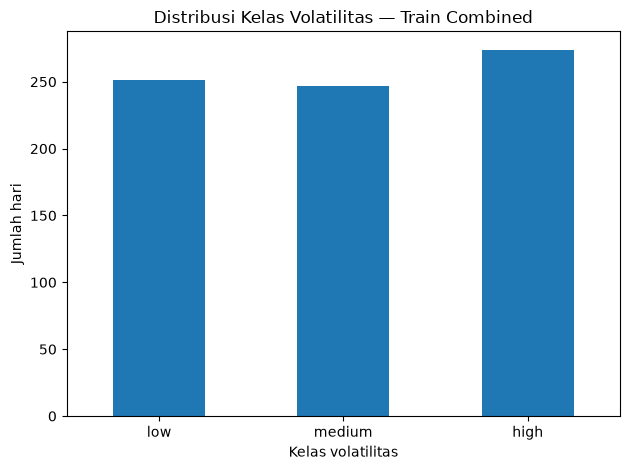

In [5]:
counts = eda_train.volatility_class.value_counts().reindex(classes, fill_value=0)
display(pd.DataFrame({'count': counts, 'percentage': (counts / len(eda_train) * 100).round(2)}))
ax = counts.plot.bar(rot=0, title='Distribusi Kelas Volatilitas — Train Combined')
ax.set_xlabel('Kelas volatilitas'); ax.set_ylabel('Jumlah hari')
plt.tight_layout(); plt.show()


## 3. Pergerakan JISDOR dan `log_return`

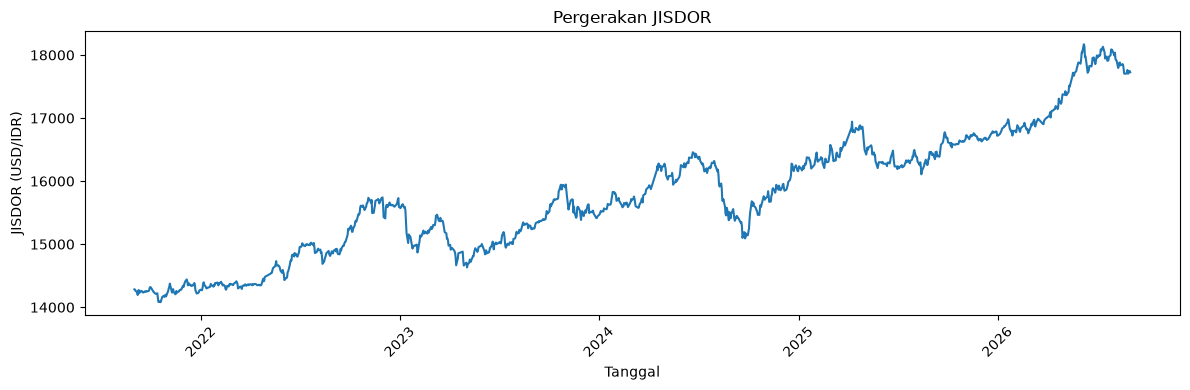

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["kurs"])
ax.set_title("Pergerakan JISDOR")
ax.set_xlabel("Tanggal")
ax.set_ylabel("JISDOR (USD/IDR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

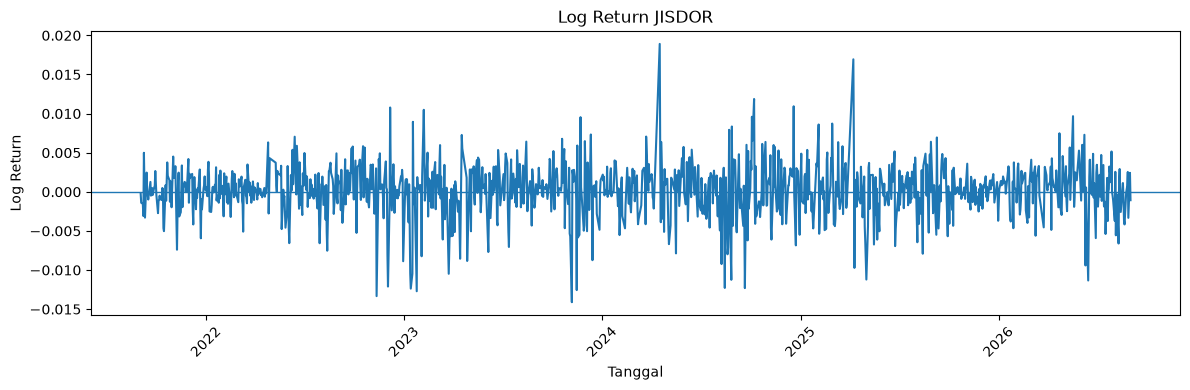

count    1201.000000
mean        0.000180
std         0.003335
min        -0.014112
25%        -0.001479
50%         0.000385
75%         0.002097
max         0.018909
Name: log_return, dtype: float64

In [7]:
log_return = df["log_return"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.loc[df["log_return"].notna(), "date"], log_return)
ax.axhline(0, linewidth=1)
ax.set_title("Log Return JISDOR")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Log Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(df["log_return"].describe())

### Pergerakan realized volatility


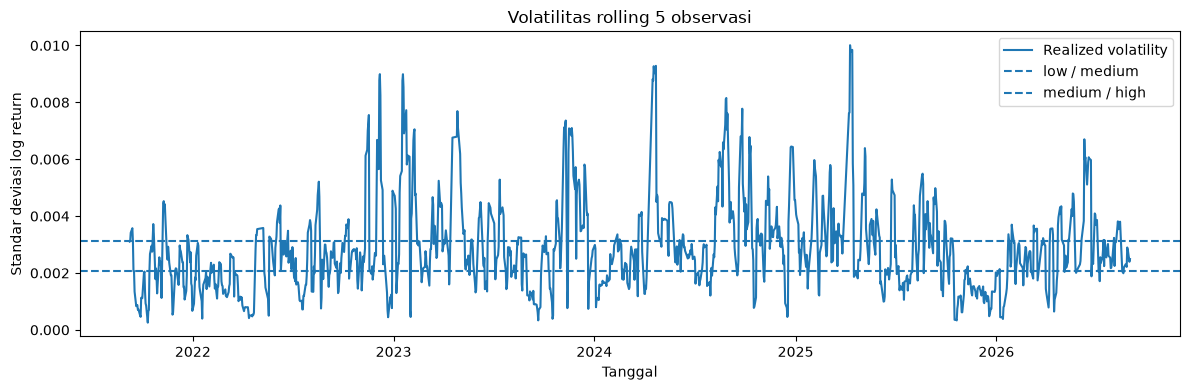

count    1197.000000
mean        0.002886
std         0.001625
min         0.000255
25%         0.001778
50%         0.002613
75%         0.003577
max         0.010010
Name: realized_vol, dtype: float64

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.date, df.realized_vol, label='Realized volatility')
for cutoff, name in zip(edges[1:-1], ['low / medium', 'medium / high']):
    ax.axhline(cutoff, linestyle='--', label=name)
ax.set(title=f'Volatilitas rolling {C.VOLATILITY_WINDOW} observasi',
       xlabel='Tanggal', ylabel='Standar deviasi log return')
ax.legend(); plt.tight_layout(); plt.show()
display(df.realized_vol.describe())


## 4. Distribusi jumlah berita (`n_news`)

,n_news
count,1202.000000
mean,5.002496
std,6.795269
min,0.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,139.000000


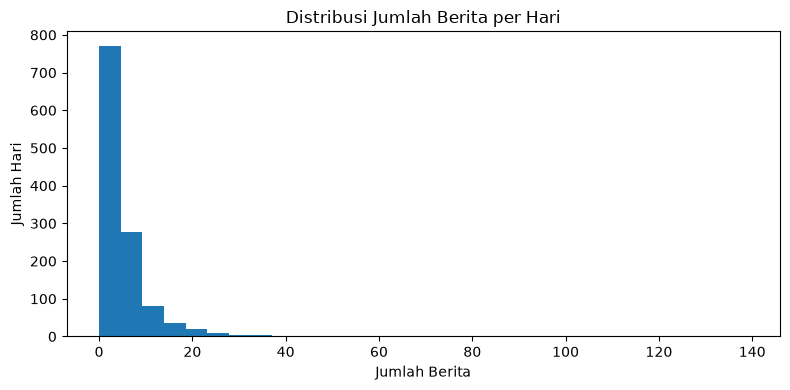

Hari tanpa berita: 94
Hari dengan berita: 1108


In [9]:
display(df["n_news"].describe().to_frame("n_news"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["n_news"].dropna(), bins=30)
ax.set_title("Distribusi Jumlah Berita per Hari")
ax.set_xlabel("Jumlah Berita")
ax.set_ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

print("Hari tanpa berita:", (df["n_news"] == 0).sum())
print("Hari dengan berita:", (df["n_news"] > 0).sum())

## 5. Distribusi `mean_relevance`

,mean_relevance
count,1108.000000
mean,7.253352
std,2.838770
min,2.000000
25%,5.087413
50%,7.000000
75%,9.000000
max,21.000000


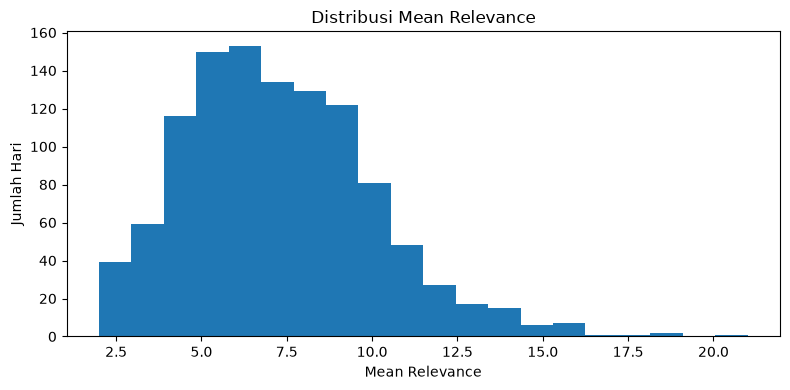

In [11]:
display(df["mean_relevance"].describe().to_frame("mean_relevance"))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["mean_relevance"].dropna(), bins=20)
ax.set_title("Distribusi Mean Relevance")
ax.set_xlabel("Mean Relevance")
ax.set_ylabel("Jumlah Hari")
plt.tight_layout()
plt.show()

## 6. Hubungan fitur berita dengan kelas volatilitas

In [12]:
# Ringkasan fitur berita berdasarkan volatility_class
news_by_volatility_class = (
    eda_train.groupby("volatility_class", observed=True, dropna=False)[["n_news", "mean_relevance", "max_relevance", "mean_tokens", "pct_offhours"]]
      .agg(["count", "mean", "median"])
)

display(news_by_volatility_class)

n_news                  mean_relevance                      \
                  count      mean median          count      mean    median   
volatility_class                                                              
low                 251  4.039841    3.0            251  7.681485  7.384615   
medium              247  3.546559    3.0            247  7.401149  7.333333   
high                274  3.974453    3.0            274  6.820682  6.516667   

                 max_relevance                   mean_tokens              \
                         count       mean median       count        mean   
volatility_class                                                           
low                        251  10.713147   11.0         251  541.144117   
medium                     247  10.554656   10.0         247  574.285508   
high                       274  10.043796   10.0         274  568.279827   

                             pct_offhours                   
                      median        count      mean median  
volatility_class                                            
low               564.636364          251  0.824739    1.0  
medium            569.833333          247  0.835777    1.0  
high              567.533333          274  0.838006    1.0

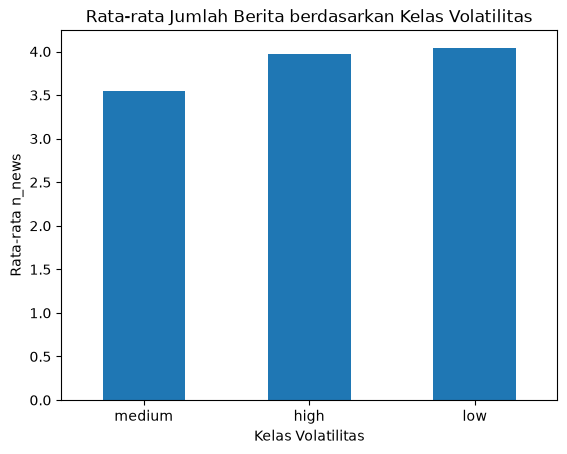

In [13]:
# Rata-rata jumlah berita per volatility_class
mean_news = eda_train.groupby("volatility_class", observed=True)["n_news"].mean().sort_values()

ax = mean_news.plot(kind="bar")
ax.set_title("Rata-rata Jumlah Berita berdasarkan Kelas Volatilitas")
ax.set_xlabel("Kelas Volatilitas")
ax.set_ylabel("Rata-rata n_news")
plt.xticks(rotation=0)
plt.show()

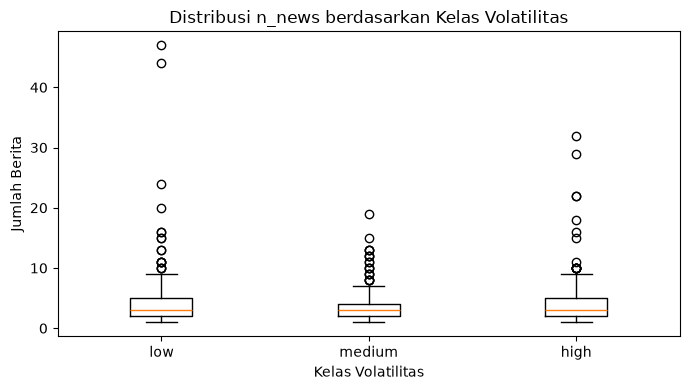

In [14]:
# Boxplot jumlah berita menurut volatility_class
groups = []
labels = []

for label, group in eda_train.groupby("volatility_class", observed=True):
    groups.append(group["n_news"].dropna())
    labels.append(label)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(groups, tick_labels=labels)
ax.set_title("Distribusi n_news berdasarkan Kelas Volatilitas")
ax.set_xlabel("Kelas Volatilitas")
ax.set_ylabel("Jumlah Berita")
plt.tight_layout()
plt.show()

### Catatan interpretasi

Bagian ini hanya mengeksplorasi **asosiasi/pola awal**. Perbedaan jumlah berita atau sentiment/relevance antar-kelas **belum membuktikan hubungan kausal** dan belum berarti fitur tersebut akan meningkatkan performa model.

## 7. Missing value

In [15]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

display(missing.sort_values("missing_count", ascending=False))

,missing_count,missing_percentage
mean_relevance,94,7.82
text_norm_concat,94,7.82
mean_lm_polarity,94,7.82
pct_offhours,94,7.82
mean_tokens,94,7.82
max_relevance,94,7.82
lag1_realized_vol,6,0.50
lag1_volatility_class,6,0.50
realized_vol,5,0.42
volatility_class,5,0.42


## 8. Pemeriksaan tanggal dan potensi masalah temporal

In [16]:
# Cek duplikasi tanggal
print("Jumlah tanggal duplikat:", df["date"].duplicated().sum())

# Cek tanggal weekend
weekend_rows = df[df["date"].dt.dayofweek >= 5][["date", "kurs", "volatility_class"]]
print("Jumlah row weekend:", len(weekend_rows))

if len(weekend_rows) > 0:
    display(weekend_rows.head(20))

# Cek urutan waktu
print("Tanggal minimum:", df["date"].min().date())
print("Tanggal maksimum:", df["date"].max().date())
print("Urutan tanggal sudah ascending:", df["date"].is_monotonic_increasing)

Jumlah tanggal duplikat: 0
Jumlah row weekend: 0
Tanggal minimum: 2021-09-01
Tanggal maksimum: 2026-09-01
Urutan tanggal sudah ascending: True


## 9. Pemeriksaan pergeseran distribusi fitur
Bagian ini membandingkan train dan validation untuk mendeteksi perubahan
distribusi fitur sebelum evaluasi akhir pada test. Pergeseran pada jumlah artikel
dapat mencerminkan perubahan cakupan scraping, sedangkan pergeseran fitur LM
dapat mengubah pola masukan yang diterima model.

In [17]:
# Ringkasan fitur train vs validation; test sengaja tidak dipakai pada EDA ini.
shift_parts = {'train': train, 'validation': validation}
shift_summary = pd.DataFrame({
    name: {
        'n_hari': len(part),
        'rata-rata artikel/hari': part['n_news'].mean(),
        'median artikel/hari': part['n_news'].median(),
        'rata-rata lm_negative_sum': part['lm_negative_sum'].mean(),
        'median lm_negative_sum': part['lm_negative_sum'].median(),
        'rata-rata LM polarity': part['mean_lm_polarity'].mean(),
    }
    for name, part in shift_parts.items()
}).T.round(3)
display(shift_summary)

article_shift = shift_summary.loc['validation', 'rata-rata artikel/hari'] - shift_summary.loc['train', 'rata-rata artikel/hari']
print(f'Perubahan rata-rata artikel per hari (validation - train): {article_shift:+.2f}')


,n_hari,rata-rata artikel/hari,median artikel/hari,rata-rata lm_negative_sum,median lm_negative_sum,rata-rata LM polarity
train,772.0,3.859,3.0,103.065,77.0,-0.542
validation,165.0,7.994,6.0,165.891,113.0,-0.397


Perubahan rata-rata artikel per hari (validation - train): +4.13


split,train,validation
year,,
2021,2.21,NaN
2022,4.55,NaN
2023,3.18,NaN
2024,3.68,NaN
2025,6.27,7.99


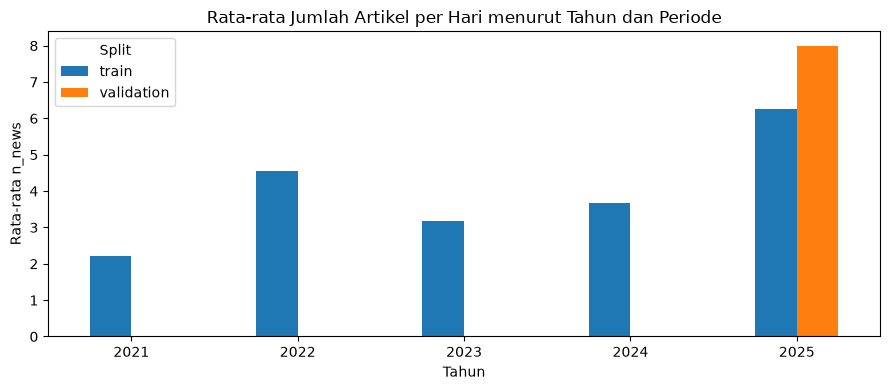

In [18]:
# Statistik scraping: rata-rata jumlah artikel per tahun dan periode.
annual_articles = pd.concat([
    part.assign(split=name, year=part['date'].dt.year)
    for name, part in shift_parts.items()
]).groupby(['year', 'split'], observed=True)['n_news'].mean().unstack()
display(annual_articles.round(2))

ax = annual_articles.plot(kind='bar', figsize=(9, 4))
ax.set_title('Rata-rata Jumlah Artikel per Hari menurut Tahun dan Periode')
ax.set_xlabel('Tahun'); ax.set_ylabel('Rata-rata n_news')
ax.legend(title='Split'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


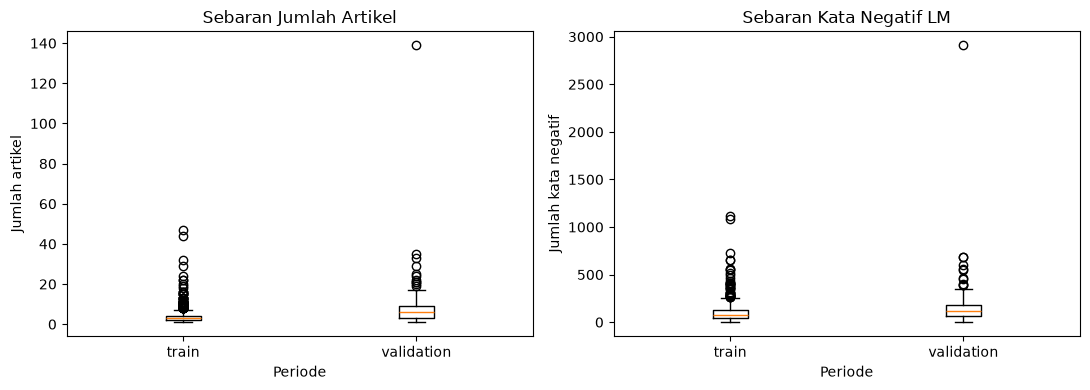

In [19]:
# Bandingkan sebaran jumlah artikel dan kata negatif LM antarperiode.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feature, title, ylabel in [
    (axes[0], 'n_news', 'Sebaran Jumlah Artikel', 'Jumlah artikel'),
    (axes[1], 'lm_negative_sum', 'Sebaran Kata Negatif LM', 'Jumlah kata negatif'),
]:
    values = [shift_parts[name][feature].dropna() for name in shift_parts]
    ax.boxplot(values, tick_labels=list(shift_parts))
    ax.set_title(title); ax.set_xlabel('Periode'); ax.set_ylabel(ylabel)
plt.tight_layout(); plt.show()


## Output dan batas interpretasi

Notebook menghasilkan audit kalender, distribusi kelas low/medium/high,
visualisasi kurs, log return dan volatilitas, dan hubungan fitur berita dengan kelas
pada train.
Proporsi kelas validation/test tidak harus seimbang karena threshold tetap.

Volatilitas rolling berurutan berbagi sebagian besar return. Karena itu,
model harus dibandingkan dengan persistence (kelas hari sebelumnya).
Hubungan fitur berita dengan kelas tidak membuktikan hubungan kausal.
Split ini mengikuti `build_dataset(required_cols=PRICE_FEATURES + LM_FEATURES)`;
script lain dengan required_cols berbeda dapat memiliki cohort train berbeda.
